In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv', on_bad_lines='skip')

print(df.shape)
print(df.columns.tolist())
df.head()

(44424, 10)
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [2]:
print(f"Total rows: {len(df)}")
print(f"Unique articleTypes: {df['articleType'].nunique()}\n")

counts = df['articleType'].value_counts()
print(counts)

Total rows: 44424
Unique articleTypes: 143

articleType
Tshirts                7067
Shirts                 3217
Casual Shoes           2845
Watches                2542
Sports Shoes           2036
                       ... 
Cushion Covers            1
Mens Grooming Kit         1
Body Wash and Scrub       1
Suits                     1
Ipad                      1
Name: count, Length: 143, dtype: int64


In [3]:
MIN_SAMPLES = 200

valid_classes = counts[counts >= MIN_SAMPLES].index.tolist()
df_filtered = df[df['articleType'].isin(valid_classes)].copy()

print(f"Classes kept: {len(valid_classes)}")
print(f"Rows after filter: {len(df_filtered)}")
print(f"\nClasses: {valid_classes}")

Classes kept: 40
Rows after filter: 40163

Classes: ['Tshirts', 'Shirts', 'Casual Shoes', 'Watches', 'Sports Shoes', 'Kurtas', 'Tops', 'Handbags', 'Heels', 'Sunglasses', 'Wallets', 'Flip Flops', 'Sandals', 'Briefs', 'Belts', 'Backpacks', 'Socks', 'Formal Shoes', 'Perfume and Body Mist', 'Jeans', 'Shorts', 'Trousers', 'Flats', 'Bra', 'Dresses', 'Sarees', 'Earrings', 'Deodorant', 'Nail Polish', 'Lipstick', 'Track Pants', 'Clutches', 'Sweatshirts', 'Caps', 'Sweaters', 'Ties', 'Jackets', 'Innerwear Vests', 'Kurtis', 'Tunics']


In [4]:
import os

IMG_DIR = '/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images'

df_filtered['image_path'] = df_filtered['id'].astype(str).apply(
    lambda x: os.path.join(IMG_DIR, x + '.jpg')
)

df_filtered = df_filtered[df_filtered['image_path'].apply(os.path.exists)].copy()

print(f"Rows after image existence check: {len(df_filtered)}")
print(df_filtered['image_path'].iloc[0])  # sanity check one path

Rows after image existence check: 40159
/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images/15970.jpg


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['articleType'])

print(f"Number of classes: {len(le.classes_)}")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Number of classes: 40
{'Backpacks': np.int64(0), 'Belts': np.int64(1), 'Bra': np.int64(2), 'Briefs': np.int64(3), 'Caps': np.int64(4), 'Casual Shoes': np.int64(5), 'Clutches': np.int64(6), 'Deodorant': np.int64(7), 'Dresses': np.int64(8), 'Earrings': np.int64(9), 'Flats': np.int64(10), 'Flip Flops': np.int64(11), 'Formal Shoes': np.int64(12), 'Handbags': np.int64(13), 'Heels': np.int64(14), 'Innerwear Vests': np.int64(15), 'Jackets': np.int64(16), 'Jeans': np.int64(17), 'Kurtas': np.int64(18), 'Kurtis': np.int64(19), 'Lipstick': np.int64(20), 'Nail Polish': np.int64(21), 'Perfume and Body Mist': np.int64(22), 'Sandals': np.int64(23), 'Sarees': np.int64(24), 'Shirts': np.int64(25), 'Shorts': np.int64(26), 'Socks': np.int64(27), 'Sports Shoes': np.int64(28), 'Sunglasses': np.int64(29), 'Sweaters': np.int64(30), 'Sweatshirts': np.int64(31), 'Ties': np.int64(32), 'Tops': np.int64(33), 'Track Pants': np.int64(34), 'Trousers': np.int64(35), 'Tshirts': np.int64(36), 'Tunics': np.int64(37), 'W

In [6]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_filtered[['image_path', 'label']], 
    test_size=0.2, 
    random_state=42,
    stratify=df_filtered['label']
)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")

Train size: 32127
Val size:   8032


In [7]:
import tensorflow as tf 

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 40

def load_and_preprocess(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta = 0.2)
    image = tf.image.random_contrast(image, lower = 0.8, upper = 1.2)
    return image, label

# train dataset generator
train_ds = tf.data.Dataset.from_tensor_slices((
    train_df['image_path'].values,
    train_df['label'].values
))

train_ds = (
    train_ds
    .map(load_and_preprocess, num_parallel_calls = tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls = tf.data.AUTOTUNE)
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# val dataset generator - no shuffle and no augmentation
val_ds = tf.data.Dataset.from_tensor_slices((
    val_df['image_path'].values,
    val_df['label'].values
))

val_ds = (
    val_ds
    .map(load_and_preprocess, num_parallel_calls = tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

2026-06-08 07:23:48.033823: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780903428.217986      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780903428.273462      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780903428.727771      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780903428.727806      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780903428.727808      58 computation_placer.cc:177] computation placer alr

In [8]:
print("Train batches:", len(train_ds))
print("Val batches:  ", len(val_ds))

Train batches: 1004
Val batches:   251


In [9]:
from tensorflow import keras
from keras import layers, Model

strategy = tf.distribute.MirroredStrategy()  # uses both T4s
print(f"Number of devices: {strategy.num_replicas_in_sync}")

with strategy.scope():
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,200 (9.90 MB)

 Trainable params: 338,216 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,200 (9.90 MB)

 Trainable params: 338,216 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1780903484.178970     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780903484.180310     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


1004/1004 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.7517 - loss: 0.8497INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 336s 311ms/step - accuracy: 0.8108 - loss: 0.5881 - val_accuracy: 0.8670 - val_loss: 0.3784 - learning_rate: 0.0010
Epoch 2/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 276s 261ms/step - accuracy: 0.8644 - loss: 0.3899 - val_accuracy: 0.8704 - val_loss: 0.3696 - learning_rate: 0.0010
Epoch 3/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 279s 264ms/step - accuracy: 0.8752 - loss: 0.3503 - val_accuracy: 0.8782 - val_loss: 0.3503 - learning_rate: 0.0010
Epoch 4/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 274s 260ms/step - accuracy: 0.8866 - loss: 0.3143 - val_accuracy: 0.8766 - val_loss: 0.3511 - learning_rate: 0.0010
Epoch 5/10
1003/1004 

In [12]:
with strategy.scope():
    base_model.trainable = True
    
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print(f"Trainable params: {sum([w.numpy().size for w in model.trainable_weights])}")

Trainable params: 1864616


In [13]:
history_fine = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 36 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 295s 269ms/step - accuracy: 0.8471 - loss: 0.4611 - val_accuracy: 0.8960 - val_loss: 0.3271 - learning_rate: 1.0000e-05
Epoch 2/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 281s 267ms/step - accuracy: 0.8818 - loss: 0.3314 - val_accuracy: 0.8973 - val_loss: 0.3140 - learning_rate: 1.0000e-05
Epoch 3/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 288s 273ms/step - accuracy: 0.8953 - loss: 0.2943 - val_accuracy: 0.8990 - val_loss: 0.2996 - learning_rate: 1.0000e-05
Epoch 4/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 289s 274ms/step - accuracy: 0.9065 - loss: 0.2637 - val_accuracy: 0.9020 - val_loss: 0.2959 - learning_rate: 1.0000e-05
Epoch 5/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 282s 267ms/step - accuracy: 0.9129 - loss: 0.2444 - val_accuracy: 0.9061 - val_loss: 0.2838 - learning_rate: 1.0000e-05
Epoch 6/10
1004/1004 ━━━━━━━━

In [14]:
history_fine2 = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

Epoch 1/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 281s 267ms/step - accuracy: 0.9345 - loss: 0.1791 - val_accuracy: 0.9120 - val_loss: 0.2713 - learning_rate: 1.0000e-05
Epoch 2/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 280s 266ms/step - accuracy: 0.9391 - loss: 0.1669 - val_accuracy: 0.9107 - val_loss: 0.2718 - learning_rate: 1.0000e-05
Epoch 3/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 286s 270ms/step - accuracy: 0.9411 - loss: 0.1625 - val_accuracy: 0.9135 - val_loss: 0.2693 - learning_rate: 1.0000e-05
Epoch 4/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 299s 284ms/step - accuracy: 0.9455 - loss: 0.1499 - val_accuracy: 0.9128 - val_loss: 0.2683 - learning_rate: 1.0000e-05
Epoch 5/10
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 283s 268ms/step - accuracy: 0.9478 - loss: 0.1416 - val_accuracy: 0.9133 - val_loss: 0.2702 - learning_rate: 1.0000e-05
Epoch 6/10
1003/1004 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9479 - loss: 0.1400
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
1004/1004 ━━━━━━━━━━━━━━

In [15]:
model.save('/kaggle/working/fashion_classifier.keras')
print("Saved!")

Saved!


In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# get predictions on val set
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

print(classification_report(y_true, y_pred, target_names=le.classes_))

                       precision    recall  f1-score   support

            Backpacks       0.96      0.94      0.95       145
                Belts       0.99      0.99      0.99       163
                  Bra       0.99      0.99      0.99        95
               Briefs       0.99      0.99      0.99       170
                 Caps       1.00      0.95      0.97        57
         Casual Shoes       0.85      0.85      0.85       569
             Clutches       0.86      0.86      0.86        58
            Deodorant       0.99      0.99      0.99        69
              Dresses       0.82      0.81      0.82        93
             Earrings       1.00      0.98      0.99        83
                Flats       0.48      0.39      0.43       100
           Flip Flops       0.90      0.89      0.89       183
         Formal Shoes       0.86      0.91      0.88       127
             Handbags       0.97      0.96      0.97       352
                Heels       0.77      0.80      0.79  

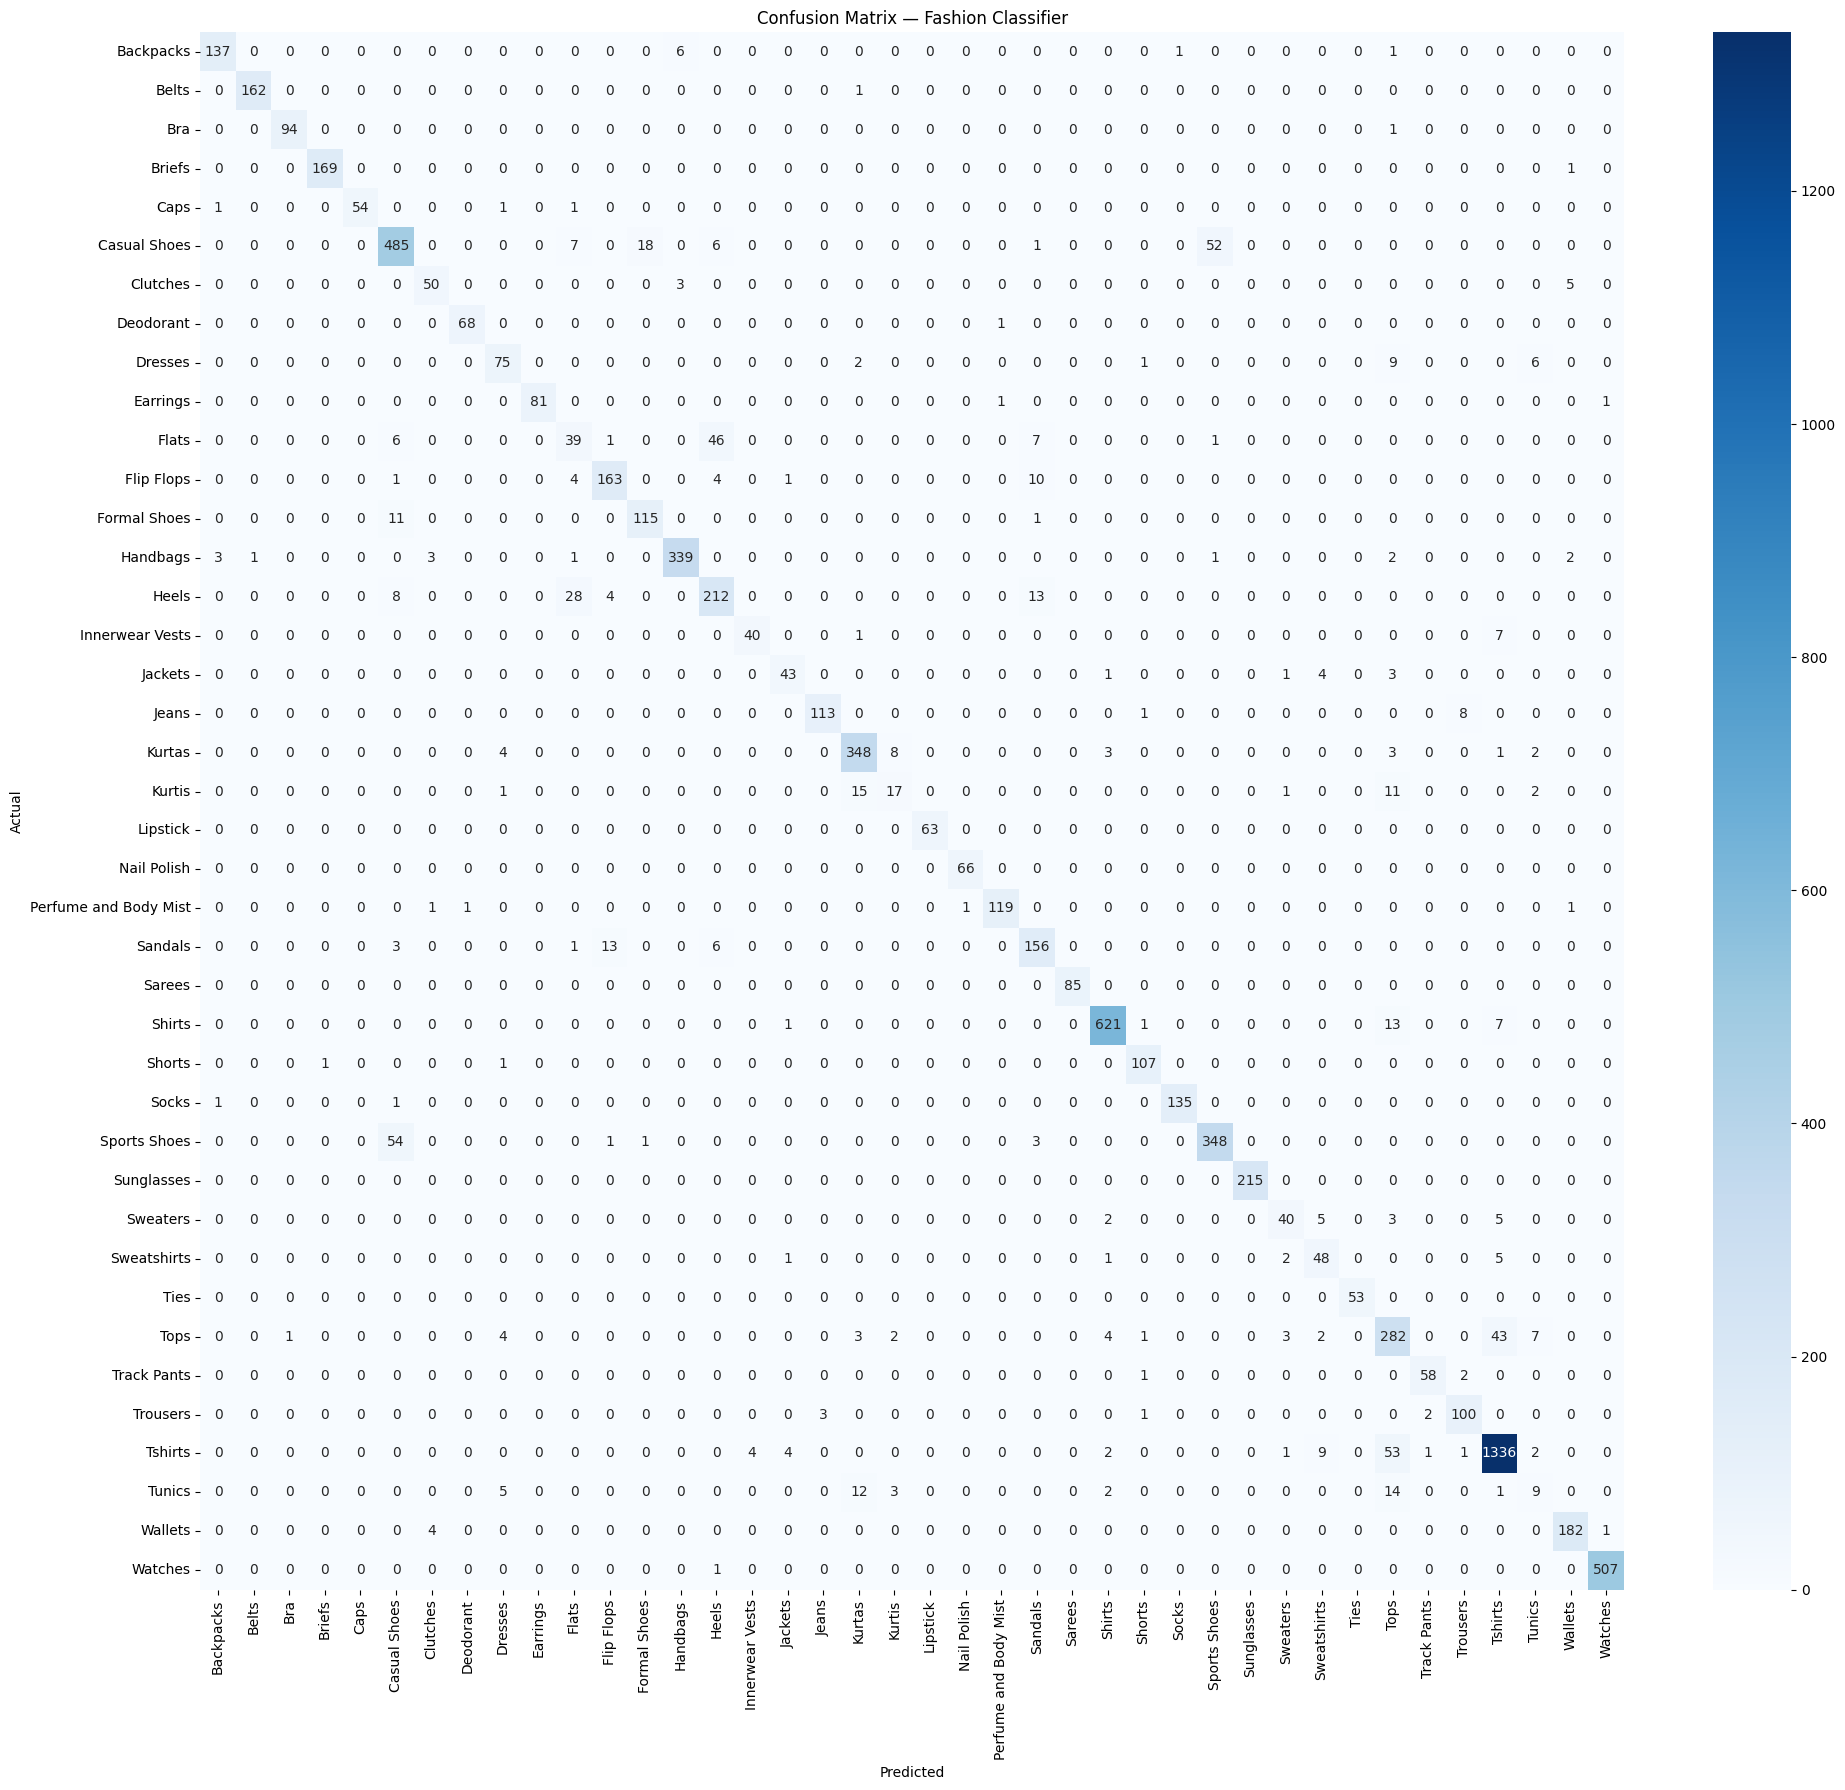

In [17]:
plt.figure(figsize=(20, 18))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Fashion Classifier')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

In [18]:
# save model
model.save('/kaggle/working/fashion_classifier.keras')

# save label encoder classes
import numpy as np
np.save('/kaggle/working/label_classes.npy', le.classes_)

In [19]:
loaded_classes = np.load('/kaggle/working/label_classes.npy', allow_pickle=True)
print("Classes saved:", loaded_classes)

Classes saved: ['Backpacks' 'Belts' 'Bra' 'Briefs' 'Caps' 'Casual Shoes' 'Clutches'
 'Deodorant' 'Dresses' 'Earrings' 'Flats' 'Flip Flops' 'Formal Shoes'
 'Handbags' 'Heels' 'Innerwear Vests' 'Jackets' 'Jeans' 'Kurtas' 'Kurtis'
 'Lipstick' 'Nail Polish' 'Perfume and Body Mist' 'Sandals' 'Sarees'
 'Shirts' 'Shorts' 'Socks' 'Sports Shoes' 'Sunglasses' 'Sweaters'
 'Sweatshirts' 'Ties' 'Tops' 'Track Pants' 'Trousers' 'Tshirts' 'Tunics'
 'Wallets' 'Watches']


In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def predict_single(image_path):
    # load and preprocess
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    img = tf.expand_dims(img, axis=0)  # add batch dimension

    # predict
    preds = model.predict(img, verbose=0)
    top3_idx = np.argsort(preds[0])[::-1][:3]
    
    # show image
    original = mpimg.imread(image_path)
    plt.imshow(original)
    plt.axis('off')
    plt.title(f"Top 3 Predictions:", fontsize=12)
    plt.show()

    for i, idx in enumerate(top3_idx):
        print(f"  {i+1}. {le.classes_[idx]:25s} {preds[0][idx]*100:.1f}%")

True label: Flip Flops



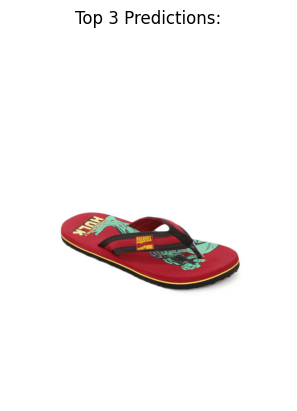

  1. Flip Flops                99.8%
  2. Flats                     0.1%
  3. Heels                     0.1%


In [21]:
sample = val_df.sample(1).iloc[0]
print(f"True label: {le.classes_[sample['label']]}\n")
predict_single(sample['image_path'])

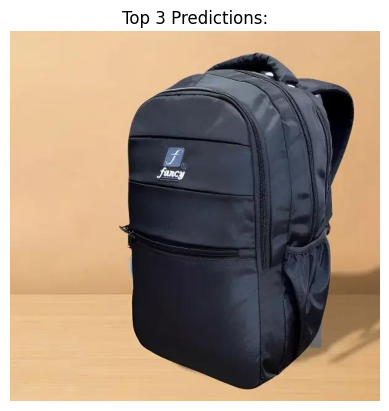

  1. Backpacks                 100.0%
  2. Handbags                  0.0%
  3. Caps                      0.0%


In [25]:
import requests
from PIL import Image
from io import BytesIO

url = 'https://cdn.dotpe.in/longtail/store-items/6590180/OMLnq5KF.webp'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img.save('/kaggle/working/test_img.jpg')
predict_single('/kaggle/working/test_img.jpg')

In [26]:
import json

# 1. model already saved, confirm
print("Model:", os.path.exists('/kaggle/working/fashion_classifier.keras'))
print("Classes:", os.path.exists('/kaggle/working/label_classes.npy'))

# 2. save training history
history_all = {
    'phase1': history.history,
    'phase2': history_fine.history,
}
with open('/kaggle/working/training_history.json', 'w') as f:
    json.dump(history_all, f)

# 3. save confusion matrix image (already done)
print("Confusion matrix:", os.path.exists('/kaggle/working/confusion_matrix.png'))

print("\nAll files:")
import glob
for f in glob.glob('/kaggle/working/*'):
    print(f)

Model: True
Classes: True
Confusion matrix: True

All files:
/kaggle/working/training_history.json
/kaggle/working/confusion_matrix.png
/kaggle/working/label_classes.npy
/kaggle/working/fashion_classifier.keras
/kaggle/working/test_img.jpg
